In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from swot import browse_swot_2km, add_grid_metrics, rotate_ggd

In [2]:
dfs = browse_swot_2km().reset_index()
dss = xr.open_dataset(dfs.file.iloc[0])
dss = add_grid_metrics(dss)

In [3]:
sla = dss.duacs_ssha_karin_2_filtered.isel(
    num_lines=slice(150, 200), num_pixels=slice(10, 30)
)

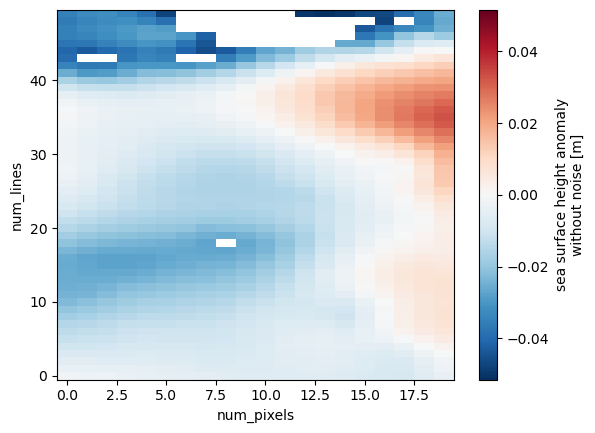

In [4]:
sla.plot()

# Fitting kernel filter inspired from Tranchant et al. 2025

- for 2D fitting : https://stackoverflow.com/questions/33964913/equivalent-of-polyfit-for-a-2d-polynomial-in-python
- for to apply : https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.generic_filter.html#scipy.ndimage.generic_filter

import numpy as np
from scipy import datasets
from scipy.ndimage import generic_filter
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def fitting(image):
    if isinstance(image, xr.DataArray): image = image.values
    x = np.arange(image.shape[0])
    y = np.arange(image.shape[1])
    X, Y = np.meshgrid(x, y, copy=False)
    X = X.flatten()
    Y = Y.flatten()

    Z=image.flatten()

    # Process 2D inputs
    poly = PolynomialFeatures(degree=2)
    input_pts = np.stack([X, Y]).T
    assert(input_pts.shape == (image.shape[0]*image.shape[1], 2))
    in_features = poly.fit_transform(input_pts)
    
    # Linear regression
    model = LinearRegression(fit_intercept=False)
    print(Z)
    model.fit(in_features,Z)

    # Display coefficients
    print(dict(zip(poly.get_feature_names_out(), model.coef_.round(4))))

    Zm = model.predict(poly.transform(input_pts))

    fitted_image = np.reshape(Zm, image.shape)
    return fitted_image


In [5]:
import numpy as np
from scipy import datasets
from scipy.ndimage import generic_filter
import matplotlib.pyplot as plt


def fitting(image):
    n = int(np.sqrt(image.shape[0]))
    if isinstance(image, xr.DataArray):
        image = image.values
    x = np.arange(n)
    y = np.arange(n)
    X, Y = np.meshgrid(x, y, copy=False)
    X, Y = np.meshgrid(x, y, copy=False)

    X = X.flatten()
    Y = Y.flatten()

    A = np.array(
        [
            X * 0 + 1,
            X,
            Y,
            X**2,
            X**2 * Y,
            X**2 * Y**2,
            Y**2,
            X * Y**2,
            X * Y,
        ]
    ).T

    coeff, r, rank, s = np.linalg.lstsq(A, image)

    Zm = A.dot(coeff)
    fitted_image = np.reshape(Zm, (n, n))
    return fitted_image

In [6]:
def fitting_kernel(image):
    fitted_image = fitting(image)
    lx, ly = fitted_im.shape
    return float(fitted_image[lx // 2, ly // 2])


def apply_fitting_kernel_filter(image, npts):
    return generic_filter(image, fitting_kernel, [npts, npts])

-0.00613812244897959


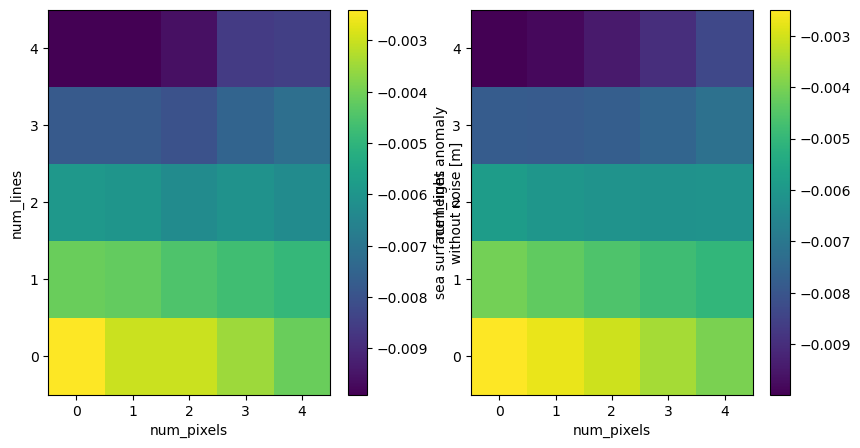

In [7]:
im_ = sla.isel(num_lines=slice(0, 5), num_pixels=slice(0, 5))  # .values
fitted_im = xr.DataArray(fitting(np.array(im_).flatten()), dims=im_.dims)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
im_.plot(ax=axs[0])
fitted_im.plot(ax=axs[1])
print(fitting_kernel(np.array(im_).flatten()))

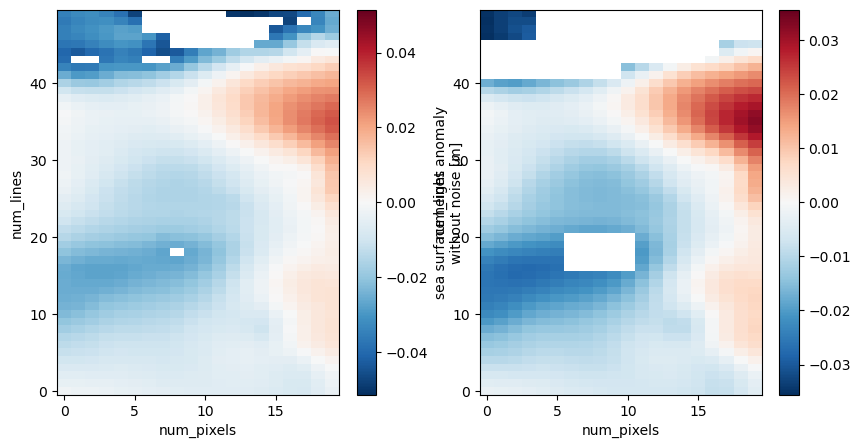

In [8]:
f = xr.DataArray(generic_filter(sla, fitting_kernel, size=[5, 5]), dims=sla.dims)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
sla.plot(ax=axs[0])
f.plot(ax=axs[1])

In [9]:
def fitting_coeff(image, var):
    """
    var must be in 'cste', 'dx', 'dy', 'dxx', 'dyy', 'dxy'
    """
    meaning_coeff = {"cste": 0, "dx": 1, "dy": 2, "dxx": 3, "dyy": 4, "dxy": 5}
    assert (
        var in meaning_coeff.keys()
    ), "var must be in 'cste', 'dx', 'dy', 'dxx', 'dyy', 'dxy'"
    n = int(np.sqrt(image.shape[0]))
    if isinstance(image, xr.DataArray):
        image = image.values
    x = np.arange(n)
    y = np.arange(n)
    X, Y = np.meshgrid(x, y, copy=False)
    X, Y = np.meshgrid(x, y, copy=False)

    X = X.flatten()
    Y = Y.flatten()

    A = np.array([X * 0 + 1, X, Y, X**2, Y**2, X * Y**2, X * Y]).T

    coeff, r, rank, s = np.linalg.lstsq(A, image)
    return coeff[meaning_coeff[var]]


def apply_fitting_kernel_filter(swot_image, npts, var):
    swot_image = swot_image.interpolate_na("num_pixels").interpolate_na("num_lines")
    return xr.DataArray(
        generic_filter(
            swot_image, fitting_coeff, size=[npts, npts], extra_keywords={"var": var}
        ),
        dims=swot_image.dims,
    )

(array([ 105.,  689., 1731., 2937., 3802., 3877., 2881., 1807.,  726.,
          96.]),
 array([1999.89824584, 1999.91855771, 1999.93886958, 1999.95918145,
        1999.97949332, 1999.99980518, 2000.02011705, 2000.04042892,
        2000.06074079, 2000.08105266, 2000.10136452]),
 <BarContainer object of 10 artists>)

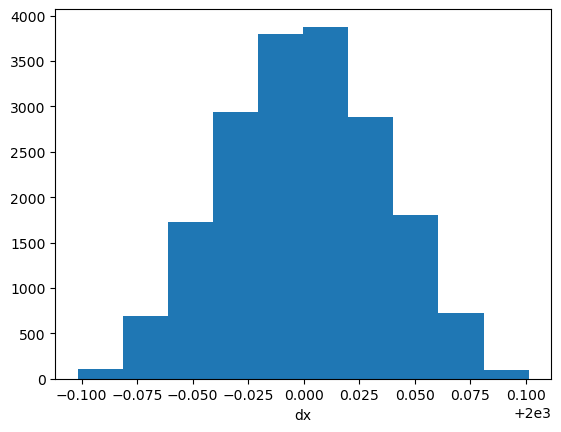

In [69]:
dss.dx.plot.hist()

In [25]:
from cstes import zarr_dir

dfs = browse_swot_2km().reset_index()
g = 9.81
dx = 2000.0
dy = 2000.0

for npts in np.arange(3, 21, 2):
    for f in dfs.file.unique():
        dss = xr.open_dataset(f)
        dss = add_grid_metrics(dss)
        dsss = xr.Dataset()
        for v in ["duacs_ssha_karin_2_calibrated", "duacs_ssha_karin_2_filtered"]:
            dsss["dx_" + v] = apply_fitting_kernel_filter(dss[v], npts, "dx") / dx
            dsss["dy_" + v] = apply_fitting_kernel_filter(dss[v], npts, "dy") / dy
            dsss["dxx_" + v] = (
                apply_fitting_kernel_filter(dss[v], npts, "dxx") / dx / dx
            )
            dsss["dyy_" + v] = (
                apply_fitting_kernel_filter(dss[v], npts, "dyy") / dy / dy
            )
            dsss["dxy_" + v] = (
                apply_fitting_kernel_filter(dss[v], npts, "dxy") / dx / dy
            )
            dsss = dsss.where(dss.duacs_editing_flag == 0)
        print(int(dss.pass_number.mean()), int(dss.cycle_number.mean()))
        dsss.to_netcdf(
            os.path.join(
                zarr_dir,
                "before_coloc",
                "2km_swot_fitting_kernel",
                f"{npts}pts_fittingkernel_{int(dss.pass_number.mean())}_{int(dss.cycle_number.mean())}.nc",
            )
        )

3 478
3 479
3 480
3 481
3 482
3 483
3 484
3 485
3 486
3 487
3 488
3 489
3 490
3 491
3 492
3 493
3 494
3 495
3 496
3 497
3 499
3 500
3 501
3 502
3 503
3 504
3 505
3 506
3 507
3 508
3 509
3 510
3 511
3 512
3 513
3 514
3 515
3 516
3 517
3 518
3 519
3 520
3 521
3 522
3 523
3 524
3 525
3 529
3 530
3 531
3 532
3 533
3 534
3 535
3 536
3 537
3 538
3 539
3 540
3 541
3 542
3 543
3 544
3 545
3 546
3 547
3 548
3 549
3 550
3 551
3 552
3 553
3 554
3 555
3 556
3 557
3 558
3 559
3 560
3 561
3 562
3 563
3 564
3 565
3 567
3 568
3 569
3 570
3 571
3 573
3 574
3 575
3 576
3 577
3 578
16 478
16 479
16 481
16 482
16 483
16 484
16 485
16 486
16 487
16 488
16 489
16 490
16 491
16 492
16 493
16 494
16 495
16 496
16 497
16 498
16 499
16 500
16 501
16 502
16 503
16 504
16 505
16 506
16 507
16 508
16 509
16 510
16 511
16 512
16 513
16 514
16 515
16 516
16 517
16 518
16 519
16 520
16 521
16 522
16 523
16 524
16 525
16 529
16 530
16 531
16 532
16 533
16 534
16 535
16 536
16 537
16 538
16 539
16 540
16 541
16 542
16 

In [12]:
sla = dss.duacs_ssha_karin_2_filtered.isel(
    num_lines=slice(150, 200), num_pixels=slice(10, 30)
)

# Getting all coeffs

In [24]:
meaning_coeff = {"cste": 0, "dx": 1, "dy": 2, "dx2": 3, "dy2": 4, "dxy": 5}

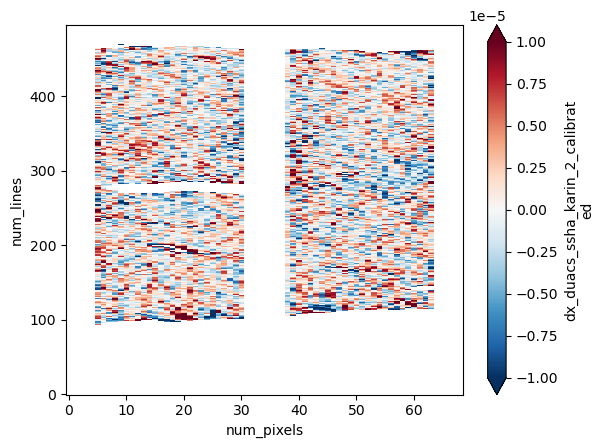

In [25]:
ds = xr.open_dataset(fg)
ds.dx_duacs_ssha_karin_2_filtered.plot(vmax=1e-5)

In [78]:
int(dss.cycle_number.mean()), int(dss.pass_number.mean())

(478, 3)

In [18]:
fg = "/Users/mdemol/DATA_MED_COLOC/before_coloc/2km_swot_fitting_kernel/3_fittingkernel_3_479.nc"

In [ ]:
dff.